In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [1]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# 20 classes, as well as none.
classes = {
    0:'None',
    1:'Aeroplane',
    2:'Bicycle',
    3:'Bird',
    4:'Boat',
    5:'Bottle',
    6:'Bus',
    7:'Car',
    8:'Cat',
    9:'Chair',
    10:'Cow',
    11:'Diningtable',
    12:'Dog',
    13:'Horse',
    14:'Motorbike',
    15:'Person',
    16:'Pottedplant',
    17:'Sheep',
    18:'Sofa',
    19:'Train',
    20:'Tvmonitor',
}
# num_classes = len(classes)
num_classes = 2

In [3]:
class OneHotMap(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, x):
        # Clip the border values (that appear as 255) to 0.
        x = torch.clamp_max(x, self.num_classes - 1)
        x = F.one_hot(x.long(), self.num_classes)
        return x.squeeze(0).permute(2, 0, 1)
        
def onehot_label(lbl, num_classes):
    c, h, w = lbl.shape # c is always 1
    out = F.one_hot(lbl, num_classes)

    return out.squeeze(0).permute(2, 0, 1)

In [14]:
# 500x500 is the max width and height in voc. Images may not be square,
# but are always equal to or smaller than 500x500.
# We use 512 since it's a nice power of 2.
voc_dim = (512,512)

train_tfs = tvt.Compose([
    tvt.PILToTensor(),
    tvt.CenterCrop((512, 512)),
    tvt.Resize((256,256), antialias=True)
])

eval_tfs = tvt.Compose([
    tvt.PILToTensor(),
    tvt.CenterCrop((512, 512)),
    tvt.Resize((256,256), antialias=True)
])

label_tfs = tvt.Compose([
    tvt.PILToTensor(),
    tvt.CenterCrop((512, 512)),
    tvt.Resize((256,256), antialias=False),
    OneHotMap(num_classes)
])

voc_train = tds.VOCSegmentation(
    root='datasets',
    download=True,
    year='2012',
    image_set='train',
    transform=train_tfs,
    target_transform=label_tfs
)

voc_val = tds.VOCSegmentation(
    root='datasets',
    download=True,
    year='2012',
    image_set='val',
    transform=eval_tfs,
    target_transform=label_tfs
)


Using downloaded and verified file: datasets/VOCtrainval_11-May-2012.tar
Extracting datasets/VOCtrainval_11-May-2012.tar to datasets
Using downloaded and verified file: datasets/VOCtrainval_11-May-2012.tar
Extracting datasets/VOCtrainval_11-May-2012.tar to datasets


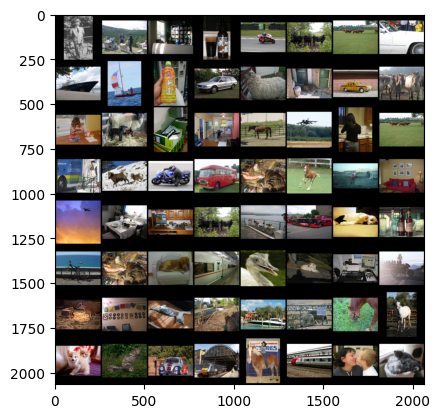

In [15]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(voc_train, k=num)])
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())

In [16]:
batchsize = 16

train_loader = tud.DataLoader(
    voc_train,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)
val_loader = tud.DataLoader(
    voc_val,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)

In [17]:
class DownConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.conv_1 = nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1)
        self.bn_1 = nn.BatchNorm2d(cout)
        self.conv_2 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)

    def forward(self, x):
        x = self.conv_1(x)
        x = F.relu(x)
        x = self.bn_1(x)
        
        x = self.conv_2(x)
        x = F.relu(x)
        x = self.bn_2(x)

        x = F.max_pool2d(x, kernel_size=2) 
        return x

class UpConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.upconv_1 = nn.ConvTranspose2d(cin, cout, kernel_size=2, stride=2)
        self.bn_1 = nn.BatchNorm2d(cout)
        self.conv_2 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)

    def forward(self, x):
        x = self.upconv_1(x)
        x = self.bn_1(x)
        
        x = self.conv_2(x)
        x = F.relu(x)
        x = self.bn_2(x)
        
        return x
    
class SimpleSeg(nn.Module):
    def __init__(self, cin, cout=num_classes, num_filters=32):
        super().__init__()
        self.l1 = DownConv(cin, num_filters)
        self.l2 = DownConv(num_filters, num_filters*2)
        self.l3 = DownConv(num_filters*2, num_filters*4)
    
        self.l4 = UpConv(num_filters*4, num_filters*2)
        self.l5 = UpConv(num_filters*2, num_filters)
        self.l6 = UpConv(num_filters, num_filters)
        self.l7 = nn.Conv2d(num_filters, num_classes, kernel_size=1, stride=1)

    def forward(self, x):
        # Down
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)

        # Up
        x = self.l4(x)
        x = self.l5(x)
        x = self.l6(x)

        # Output
        x = self.l7(x)
        x = F.softmax(x, dim=1)
        return x

In [18]:
from torchinfo import summary
testmodel = SimpleSeg(3, num_classes)
lossfn = nn.CrossEntropyLoss()
print(summary(testmodel, (1, 3, 512, 512)))

a = testmodel(torch.randn(1, 3, 512, 512).cuda())
b = lossfn(a, torch.randn(1, num_classes, 512, 512).cuda())

Layer (type:depth-idx)                   Output Shape              Param #
SimpleSeg                                [1, 2, 512, 512]          --
├─DownConv: 1-1                          [1, 32, 256, 256]         --
│    └─Conv2d: 2-1                       [1, 32, 512, 512]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 512, 512]         64
│    └─Conv2d: 2-3                       [1, 32, 512, 512]         9,248
│    └─BatchNorm2d: 2-4                  [1, 32, 512, 512]         64
├─DownConv: 1-2                          [1, 64, 128, 128]         --
│    └─Conv2d: 2-5                       [1, 64, 256, 256]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 256, 256]         128
│    └─Conv2d: 2-7                       [1, 64, 256, 256]         36,928
│    └─BatchNorm2d: 2-8                  [1, 64, 256, 256]         128
├─DownConv: 1-3                          [1, 128, 64, 64]          --
│    └─Conv2d: 2-9                       [1, 128, 128, 128]        73,8

100%|█████████████████████████████████████████| 92/92 [00:02<00:00, 43.62it/s]


Running val...


100%|█████████████████████████████████████████| 91/91 [00:01<00:00, 64.71it/s]


Epoch 0: 0.5078495740890503 
Current LR is [0.01]


100%|█████████████████████████████████████████| 92/92 [00:02<00:00, 44.02it/s]


...

Running val...


100%|█████████████████████████████████████████| 91/91 [00:01<00:00, 62.62it/s]


Epoch 48: 0.4533965587615967 
Current LR is [0.000625]


100%|█████████████████████████████████████████| 92/92 [00:02<00:00, 43.92it/s]

CPU times: user 9min 40s, sys: 48.1 s, total: 10min 28s
Wall time: 2min 4s


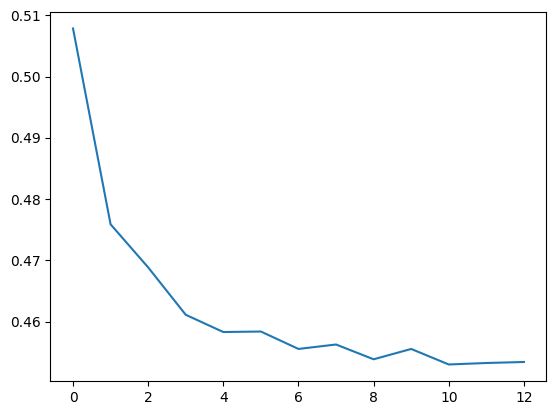

In [29]:
%%time

model = SimpleSeg(3, num_classes, num_filters=16).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
epochs = 50
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=0.1,
#     pct_start=0.15,
#     steps_per_epoch=len(train_loader),
#     epochs=epochs)

lossfn = nn.CrossEntropyLoss()
# lossfn = nn.MSELoss()
loss_plot = []
try:
    for epoch in range(epochs):
        model.train()
        for i, (images, target) in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            images = images.float().to(device)
            targets = target.float().to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets)
            loss.backward()
            optimizer.step()
            # scheduler.step()

        if epoch % 4 == 0:
            losses = []
            model.eval()
            correct = 0
            total = len(voc_val)
            print("Running val...")
            with torch.no_grad():
                for i, (images, target) in enumerate(tqdm(val_loader)):
                    images = images.float().to(device)
                    targets = target.float().to(device)
                    outs = model(images)
        
                    loss = lossfn(outs, targets)
                    losses.append(loss.cpu().item())
                        
            epoch_loss = torch.Tensor(losses).mean().item()
            print("Epoch {}: {} ".format(epoch, epoch_loss))
            print("Current LR is {}".format(scheduler.get_last_lr()))
            loss_plot.append(epoch_loss)
        scheduler.step()
        
except KeyboardInterrupt:
    plt.plot(loss_plot)
plt.plot(loss_plot)

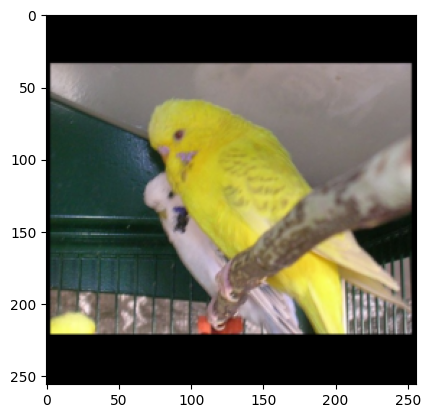

In [35]:
model.eval()

img = voc_train[25][0]
plt.imshow(img.permute(1,2,0))

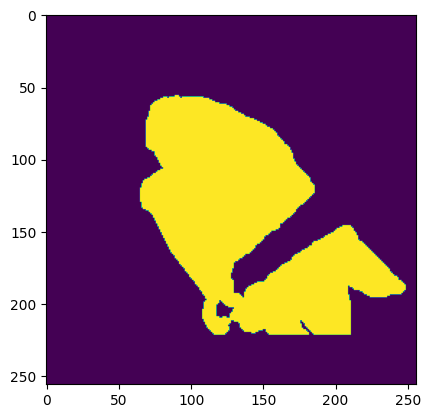

In [36]:
lbl = voc_train[20][1]
plt.imshow(lbl[1])

torch.Size([1, 2, 256, 256])


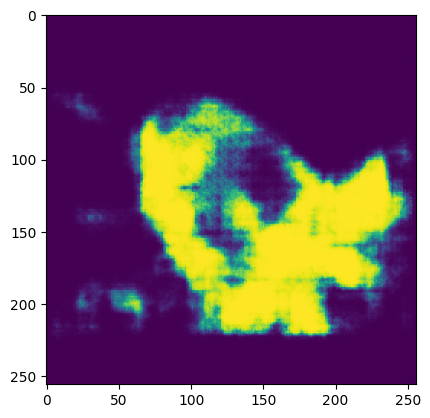

In [37]:
model.eval()
input = img.float().cuda().unsqueeze(0)

with torch.no_grad():
    pred = model(input)
    print(pred.shape)
    plt.imshow(pred[0, 1, ...].cpu())